In [ ]:
# download midis_v1.2.zip from https://drive.google.com/drive/folders/1Stz3CAvMoplo79LR5I3onMWRelCugBYS
# put the midis folder into data/raw

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing import preprocess_dataset, load_pickle
from markov import (
    train_event_unigram,
    train_event_bigram,
    train_event_second_order,
    generate_event_unigram,
    generate_event_bigram,
    generate_event_second_order
)
from midi_output import save_event_midi

random.seed(0)
np.random.seed(0)

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "midis"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("Raw dir exists:", RAW_DIR.exists())
print("Processed dir:", PROCESSED_DIR)
print("Output dir:", OUTPUT_DIR)

Project root: /Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1
Raw dir: /Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/data/raw/midis
Raw dir exists: True
Processed dir: /Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/data/processed
Output dir: /Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/outputs


In [6]:
# ONLY NEED TO RUN ONCE PER SESSION

train_songs, test_songs, failed = preprocess_dataset(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    max_files=500,
    min_events=20,
    max_chord_size=8,
    test_size=0.2,
    seed=0
)

MIDI files found: 10854
Processed 100/500 files | usable: 100 | failed: 0
Processed 200/500 files | usable: 200 | failed: 0
Processed 300/500 files | usable: 299 | failed: 0
Processed 400/500 files | usable: 399 | failed: 0
Processed 500/500 files | usable: 499 | failed: 0
Usable songs: 499
Train songs: 399
Test songs: 100
Failed files: 0


In [7]:
train_songs = load_pickle(PROCESSED_DIR / "train_songs.pkl")
test_songs = load_pickle(PROCESSED_DIR / "test_songs.pkl")
failed = load_pickle(PROCESSED_DIR / "failed_files.pkl")

print("Train songs:", len(train_songs))
print("Test songs:", len(test_songs))
print("Failed files:", len(failed))

Train songs: 399
Test songs: 100
Failed files: 0


In [8]:
example = train_songs[0]

print("Example path:", example["path"])
print("Number of events:", example["num_events"])
print("Number of notes:", example["num_notes"])
print("First 5 events:")

for event in example["events"][:5]:
    print(event)

Example path: /Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/data/raw/midis/Ascher, Joseph, Danse nègre, Op.109, R-4xx0zQXqo.mid
Number of events: 1971
Number of notes: 4961
First 5 events:
{'gap': 0, 'pitches': (30, 42), 'durations': (480, 240), 'velocities': (93, 103)}
{'gap': 360, 'pitches': (49,), 'durations': (120,), 'velocities': (83,)}
{'gap': 120, 'pitches': (51,), 'durations': (360,), 'velocities': (81,)}
{'gap': 240, 'pitches': (49,), 'durations': (120,), 'velocities': (82,)}
{'gap': 120, 'pitches': (42,), 'durations': (240,), 'velocities': (103,)}


In [9]:
all_events = [
    event
    for song in train_songs
    for event in song["events"]
]

all_pitches = [
    pitch
    for event in all_events
    for pitch in event["pitches"]
]

all_durations = [
    duration
    for event in all_events
    for duration in event["durations"]
]

all_gaps = [
    event["gap"]
    for event in all_events
]

song_event_lengths = [
    song["num_events"]
    for song in train_songs
]

chord_sizes = [
    len(event["pitches"])
    for event in all_events
]

event_intervals = []

for song in train_songs:
    melody_like_pitches = [
        max(event["pitches"])
        for event in song["events"]
        if len(event["pitches"]) > 0
    ]

    event_intervals.extend([
        b - a
        for a, b in zip(melody_like_pitches[:-1], melody_like_pitches[1:])
    ])

summary = pd.DataFrame({
    "num_train_songs": [len(train_songs)],
    "num_test_songs": [len(test_songs)],
    "num_train_events": [len(all_events)],
    "num_train_notes": [len(all_pitches)],
    "min_pitch": [min(all_pitches)],
    "max_pitch": [max(all_pitches)],
    "avg_events_per_song": [np.mean(song_event_lengths)],
    "median_events_per_song": [np.median(song_event_lengths)],
    "avg_chord_size": [np.mean(chord_sizes)],
    "max_chord_size": [max(chord_sizes)],
    "num_failed_files": [len(failed)]
})

summary

,num_train_songs,num_test_songs,num_train_events,num_train_notes,min_pitch,max_pitch,avg_events_per_song,median_events_per_song,avg_chord_size,max_chord_size,num_failed_files
0,399,100,576836,1413296,22,105,1445.704261,780.0,2.450083,8,0


##### START VIS!
Instead of flattening piano music into a one-note-at-a-time sequence, I represent each MIDI file as a sequence of onset events. Each onset event contains the time gap from the previous event, the pitches that start together, and the duration of each pitch. This representation is better suited to piano music because it preserves simultaneous notes and allows the model to generate chord-like textures directly.

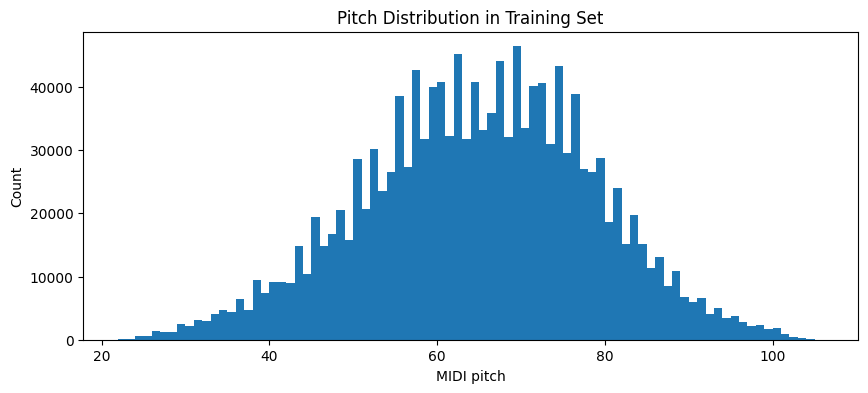

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(
    all_pitches,
    bins=range(min(all_pitches), max(all_pitches) + 2)
)
plt.xlabel("MIDI pitch")
plt.ylabel("Count")
plt.title("Pitch Distribution in Training Set")
plt.show()

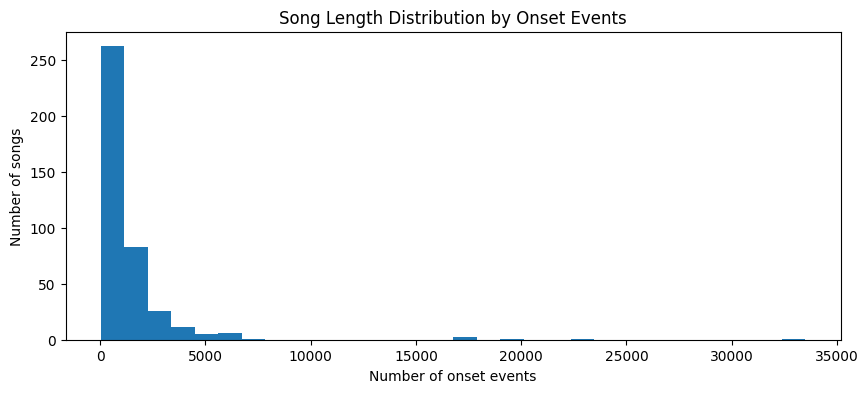

In [11]:
plt.figure(figsize=(10, 4))
plt.hist(song_event_lengths, bins=30)
plt.xlabel("Number of onset events")
plt.ylabel("Number of songs")
plt.title("Song Length Distribution by Onset Events")
plt.show()

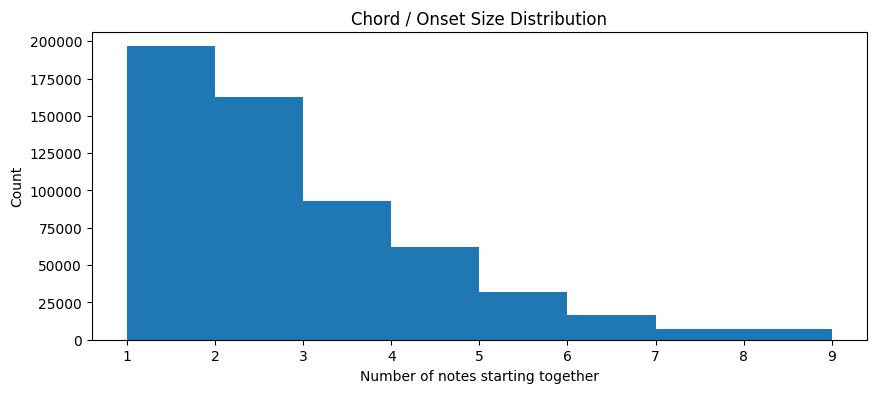

In [12]:
plt.figure(figsize=(10, 4))
plt.hist(chord_sizes, bins=range(1, max(chord_sizes) + 2))
plt.xlabel("Number of notes starting together")
plt.ylabel("Count")
plt.title("Chord / Onset Size Distribution")
plt.show()

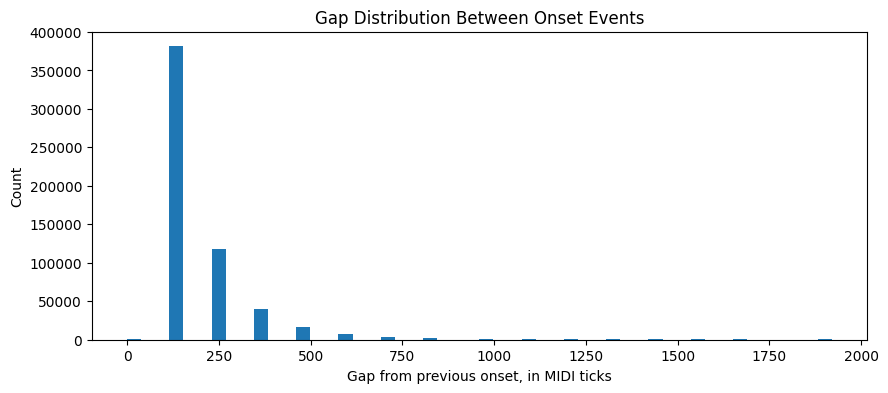

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(all_gaps, bins=50)
plt.xlabel("Gap from previous onset, in MIDI ticks")
plt.ylabel("Count")
plt.title("Gap Distribution Between Onset Events")
plt.show()

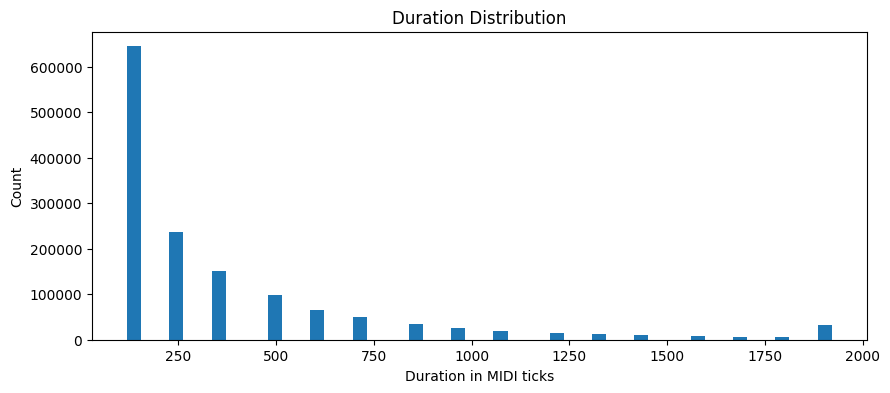

In [14]:
plt.figure(figsize=(10, 4))
plt.hist(all_durations, bins=50)
plt.xlabel("Duration in MIDI ticks")
plt.ylabel("Count")
plt.title("Duration Distribution")
plt.show()

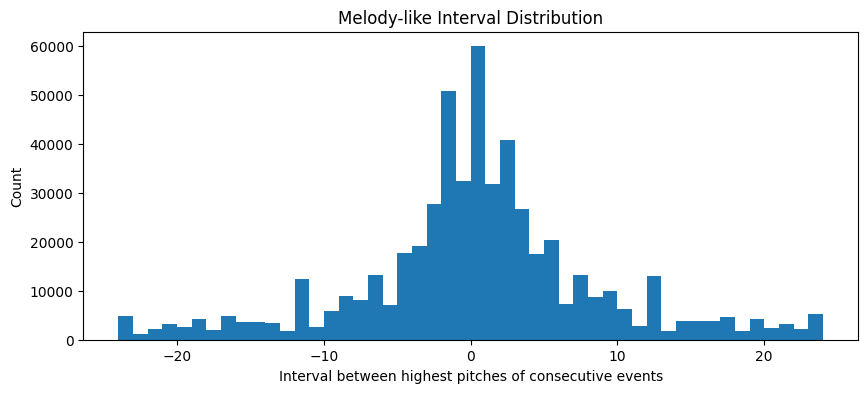

In [15]:
plt.figure(figsize=(10, 4))
plt.hist(event_intervals, bins=range(-24, 25))
plt.xlabel("Interval between highest pitches of consecutive events")
plt.ylabel("Count")
plt.title("Melody-like Interval Distribution")
plt.show()

##### ML STUFF!

This task is symbolic unconditioned generation. The model learns a distribution over onset events from the training MIDI files and samples new event sequences from that distribution.

I compare three models:

1. An event unigram baseline, which estimates p(event).
2. An event bigram Markov model, which estimates p(next event | previous event).
3. An event second-order Markov model, which estimates p(next event | previous two events).

Each event can contain multiple notes, so the model can generate chords and layered piano textures directly instead of relying on manual chord postprocessing.

In [16]:
event_unigram = train_event_unigram(train_songs)
event_bigram = train_event_bigram(train_songs)
event_second_order = train_event_second_order(train_songs)

model_summary = pd.DataFrame({
    "model_component": [
        "Event unigram model",
        "Event bigram model",
        "Event second-order model"
    ],
    "num_states": [
        len(event_unigram),
        len(event_bigram),
        len(event_second_order)
    ]
})

model_summary

,model_component,num_states
0,Event unigram model,240595
1,Event bigram model,240347
2,Event second-order model,496465


In [17]:
N_EVENTS = 300
TEMPERATURE = 0.8

unigram_events = generate_event_unigram(
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

bigram_events = generate_event_bigram(
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

second_order_events = generate_event_second_order(
    event_second_order,
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

print("Generated events:", len(second_order_events))
print("First 5 generated events:")

for event in second_order_events[:5]:
    print(event)

Generated events: 300
First 5 generated events:
{'gap': 120, 'pitches': (81,), 'durations': (120,)}
{'gap': 120, 'pitches': (79,), 'durations': (120,)}
{'gap': 240, 'pitches': (79, 84), 'durations': (120, 120)}
{'gap': 120, 'pitches': (88,), 'durations': (120,)}
{'gap': 360, 'pitches': (52, 64), 'durations': (120, 120)}


In [19]:
save_event_midi(
    unigram_events,
    OUTPUT_DIR / "event_unigram_sample.mid"
)

save_event_midi(
    bigram_events,
    OUTPUT_DIR / "event_bigram_sample.mid"
)

save_event_midi(
    second_order_events,
    OUTPUT_DIR / "symbolic_unconditioned.mid"
)

print("Saved generated MIDI files:")
print(OUTPUT_DIR / "event_unigram_sample.mid")
print(OUTPUT_DIR / "event_bigram_sample.mid")
print(OUTPUT_DIR / "symbolic_unconditioned.mid")

Saved generated MIDI files:
/Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/outputs/event_unigram_sample.mid
/Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/outputs/event_bigram_sample.mid
/Users/ayinfly/Documents/school/SP26/CSE253R/CSE153-Assignment-2-Task-1/outputs/symbolic_unconditioned.mid
